In [8]:
import argparse
import glob
import os
import sys
import numpy as np
import pandas as pd

In [9]:
def clean_columns(cols):
    """'[ C_IV ]' / ' [UNDERLYING_LAST]' -> 'c_iv' / 'underlying_last'."""
    out = []
    for c in cols:
        c = c.strip()
        if c.startswith("[") and c.endswith("]"):
            c = c[1:-1]
        out.append(c.strip().lower())
    return out
 
 
def read_optionsdx_file(path):
    # skipinitialspace handles the leading spaces OptionsDX puts after commas
    df = pd.read_csv(path, skipinitialspace=True)
    df.columns = clean_columns(df.columns)
    return df

In [10]:
def to_long(df):
    base = ["quote_date", "expire_date", "dte", "underlying_last", "strike"]
    missing = [c for c in base if c not in df.columns]
    if missing:
        raise ValueError(f"missing columns {missing}; got {list(df.columns)[:10]}...")
 
    def side(prefix, label):
        out = df[base].copy()
        out["type"] = label
        out["bid"] = pd.to_numeric(df.get(prefix + "bid"), errors="coerce")
        out["ask"] = pd.to_numeric(df.get(prefix + "ask"), errors="coerce")
        out["iv"] = pd.to_numeric(df.get(prefix + "iv"), errors="coerce")
        out["volume"] = pd.to_numeric(df.get(prefix + "volume"), errors="coerce")
        out["delta"] = pd.to_numeric(df.get(prefix + "delta"), errors="coerce")
        return out
 
    return pd.concat([side("c_", "call"), side("p_", "put")], ignore_index=True)

In [11]:
def filter_quotes(df, min_dte=7, max_dte=365, iv_cap=3.0, min_volume=0):
    df = df.copy()
    for c in ["dte", "underlying_last", "strike", "bid", "ask", "iv"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["dte", "underlying_last", "strike", "bid", "ask", "iv"])
 
    df = df[(df["bid"] > 0) & (df["ask"] >= df["bid"])]      # real two-sided quote
    df = df[(df["iv"] > 0) & (df["iv"] < iv_cap)]            # sane IV
    df = df[(df["dte"] >= min_dte) & (df["dte"] <= max_dte)]  # maturity window
    if min_volume > 0:
        df = df[df["volume"].fillna(0) >= min_volume]
 
    # keep only the OUT-OF-THE-MONEY side — the liquid, information-bearing quotes
    otm = (((df["type"] == "call") & (df["strike"] >= df["underlying_last"])) |
           ((df["type"] == "put") & (df["strike"] <= df["underlying_last"])))
    return df[otm]
 

In [12]:
def maybe_fix_iv_scale(df):
    """OptionsDX IV is decimal (0.18). If a file is in percent (18.0), rescale."""
    if len(df) and df["iv"].median() > 3.0:
        df = df.copy()
        df["iv"] = df["iv"] / 100.0
        print("  [note] IV looked like percent; divided by 100.")
    return df
 
 
def add_features(df, rate=0.0):
    df = df.copy()
    df["mid"] = 0.5 * (df["bid"] + df["ask"])
    df["tau"] = df["dte"] / 365.0
    # forward under flat rate, zero dividend. Good enough to start;
    # refine per-expiry via put-call parity later if you want.
    df["forward"] = df["underlying_last"] * np.exp(rate * df["tau"])
    df["log_moneyness"] = np.log(df["strike"] / df["forward"])
    df["total_var"] = df["iv"] ** 2 * df["tau"]
    return df

In [13]:
import re

def infer_ticker(path):
    """Ticker from the path: handles '{ticker}_eod_2023q1-xxxx/' folders and filenames."""
    for part in os.path.normpath(path).split(os.sep):
        m = re.match(r"([A-Za-z]+)_eod", part)   # 'aapl_eod_2023q1-fslib7' -> 'aapl'
        if m:
            return m.group(1).upper()
    base = os.path.basename(path)
    letters = "".join(c for c in base if c.isalpha())
    return letters.upper()[:8] or "UNKNOWN"
 
 
def save(frame, folder, name):
    pq = os.path.join(folder, name + ".parquet")
    try:
        frame.to_parquet(pq, index=False)
        return pq
    except Exception as e:          # pyarrow missing -> fall back to csv
        csv = os.path.join(folder, name + ".csv")
        frame.to_csv(csv, index=False)
        print(f"  [note] parquet failed ({e}); wrote CSV instead.")
        return csv

In [14]:
def run(input_dir, output_dir="processed", cutoff="2023-09-30",
        min_dte=7, max_dte=365, iv_cap=3.0, min_volume=0, k_max=0.5, rate=0.0,
        save_files=True):
    """Process every OptionsDX file under input_dir. Returns (df_all, train, test)."""
    files = sorted(glob.glob(os.path.join(input_dir, "**", "*.csv"), recursive=True) +
                   glob.glob(os.path.join(input_dir, "**", "*.txt"), recursive=True))
    if not files:
        raise FileNotFoundError(f"No .csv/.txt files under {input_dir}")
    print(f"Found {len(files)} file(s).")

    frames = []
    for path in files:
        tk = infer_ticker(path)
        try:
            long = to_long(read_optionsdx_file(path)); long["ticker"] = tk
            kept = filter_quotes(long, min_dte, max_dte, iv_cap, min_volume)
            kept = maybe_fix_iv_scale(kept)
            kept = add_features(kept, rate=rate)
            if k_max and k_max > 0:
                kept = kept[kept["log_moneyness"].abs() <= k_max]
            frames.append(kept)
            print(f"  {os.path.basename(path):32s} {tk:6s} kept: {len(kept):>8d}")
        except Exception as e:
            print(f"  [skip] {os.path.basename(path)}: {e}")

    df = pd.concat(frames, ignore_index=True)
    df["quote_date"]  = pd.to_datetime(df["quote_date"])
    df["expire_date"] = pd.to_datetime(df["expire_date"])
    df = df.sort_values(["ticker", "quote_date", "expire_date", "strike"]).reset_index(drop=True)

    before = len(df)                                   # safety net for duplicate folders
    df = df.drop_duplicates(subset=["ticker", "quote_date", "expire_date", "strike", "type"],
                            keep="first")
    if len(df) < before:
        print(f"[note] removed {before - len(df):,} duplicate quotes.")

    cols = ["ticker", "quote_date", "expire_date", "dte", "tau", "underlying_last", "forward",
            "strike", "log_moneyness", "type", "bid", "ask", "mid", "iv", "total_var", "delta", "volume"]
    df = df[[c for c in cols if c in df.columns]]

    cutoff_ts = pd.Timestamp(cutoff)
    train = df[df["quote_date"] <= cutoff_ts].copy()
    test  = df[df["quote_date"] >  cutoff_ts].copy()

    if save_files:
        os.makedirs(output_dir, exist_ok=True)
        save(df, output_dir, "surface_all")
        save(train, output_dir, "surface_train")
        save(test, output_dir, "surface_test")

    print(f"\n{len(df):,} clean quotes | {df['quote_date'].nunique()} dates "
          f"| {df['quote_date'].min().date()} -> {df['quote_date'].max().date()}")
    print(df.groupby('ticker').size().to_string())
    print(f"train: {len(train):,} ({train['quote_date'].nunique()} dates)  "
          f"test: {len(test):,} ({test['quote_date'].nunique()} dates)")
    return df, train, test


In [15]:
 
if __name__ == "__main__":
    df, train, test = run("OptionsData")


Found 78 file(s).
  aapl_eod_202301.txt              AAPL   kept:    10923
  aapl_eod_202302.txt              AAPL   kept:    10391
  aapl_eod_202303.txt              AAPL   kept:    11340
  aapl_eod_202304.txt              AAPL   kept:     8942
  aapl_eod_202305.txt              AAPL   kept:     9034
  aapl_eod_202306.txt              AAPL   kept:     8885
  aapl_eod_202307.txt              AAPL   kept:     8805
  aapl_eod_202308.txt              AAPL   kept:    10078
  aapl_eod_202309.txt              AAPL   kept:     8762
  aapl_eod_202310.txt              AAPL   kept:     8869
  aapl_eod_202311.txt              AAPL   kept:     8088
  aapl_eod_202312.txt              AAPL   kept:     7720
  nvda_eod_202301.txt              NVDA   kept:     9899
  nvda_eod_202302.txt              NVDA   kept:    11355
  nvda_eod_202303.txt              NVDA   kept:    13494
  nvda_eod_202304.txt              NVDA   kept:    13423
  nvda_eod_202305.txt              NVDA   kept:    18060
  nvda_eod_20

In [18]:
import matplotlib.pyplot as plt

print("Test set shape:", test.shape)
print("Date range:", test["quote_date"].min().date(), "->", test["quote_date"].max().date())
print("\nQuotes per ticker:")
print(test["ticker"].value_counts())
test.head()

Test set shape: (679076, 17)
Date range: 2023-10-02 -> 2023-12-29

Quotes per ticker:
ticker
SPX     396689
QQQ     120727
NVDA     68550
TSLA     48637
AAPL     24677
SLV      19796
Name: count, dtype: int64


,ticker,quote_date,expire_date,dte,tau,underlying_last,forward,strike,log_moneyness,type,bid,ask,mid,iv,total_var,delta,volume
87160,AAPL,2023-10-02,2023-10-13,11.0,0.030137,173.75,173.75,130.0,-0.290083,put,0.01,0.02,0.015,0.59592,0.010702,-0.00297,53.0
87161,AAPL,2023-10-02,2023-10-13,11.0,0.030137,173.75,173.75,135.0,-0.252343,put,0.01,0.02,0.015,0.52403,0.008276,-0.00272,29.0
87162,AAPL,2023-10-02,2023-10-13,11.0,0.030137,173.75,173.75,140.0,-0.215975,put,0.03,0.04,0.035,0.50050,0.007549,-0.00685,1.0
87163,AAPL,2023-10-02,2023-10-13,11.0,0.030137,173.75,173.75,145.0,-0.180884,put,0.04,0.05,0.045,0.44143,0.005873,-0.00908,49.0
87164,AAPL,2023-10-02,2023-10-13,11.0,0.030137,173.75,173.75,146.0,-0.174011,put,0.04,0.05,0.045,0.42721,0.005500,-0.00991,7.0


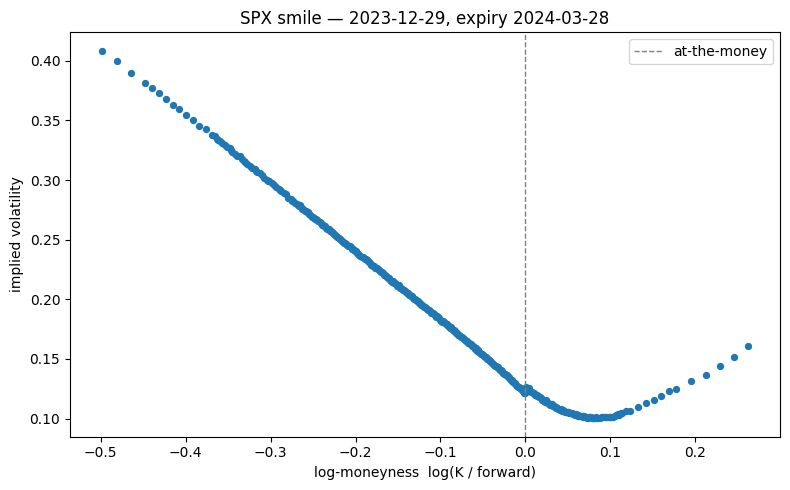

In [19]:
ticker = "SPX"                                  # pick any ticker present in test
one = test[test["ticker"] == ticker]
day = one["quote_date"].max()                   
one = one[one["quote_date"] == day]

exp = one["expire_date"].value_counts().idxmax()
smile = one[one["expire_date"] == exp].sort_values("log_moneyness")

plt.figure(figsize=(8, 5))
plt.scatter(smile["log_moneyness"], smile["iv"], s=18)
plt.axvline(0, color="grey", ls="--", lw=1, label="at-the-money")
plt.xlabel("log-moneyness  log(K / forward)")
plt.ylabel("implied volatility")
plt.title(f"{ticker} smile — {day.date()}, expiry {exp.date()}")
plt.legend(); plt.tight_layout(); plt.show()

In [20]:
import numpy as np

print("Total rows:", len(df))

checks = {
    "bid > 0"                  : (df["bid"] > 0).all(),
    "ask >= bid"               : (df["ask"] >= df["bid"]).all(),
    "iv in (0, 3)"             : df["iv"].between(0, 3, inclusive="neither").all(),
    "7 <= dte <= 365"          : df["dte"].between(7, 365).all(),
    "|log_moneyness| <= 0.5"   : (df["log_moneyness"].abs() <= 0.5).all(),
    "tau > 0"                  : (df["tau"] > 0).all(),
    "mid between bid and ask"  : ((df["mid"] >= df["bid"]) & (df["mid"] <= df["ask"])).all(),
    "no NaNs in key cols"      : df[["iv","strike","tau","log_moneyness","mid"]].notna().all().all(),
    "OTM calls: strike>=spot"  : (df.loc[df.type=="call","strike"] >= df.loc[df.type=="call","underlying_last"]).all(),
    "OTM puts: strike<=spot"   : (df.loc[df.type=="put","strike"]  <= df.loc[df.type=="put","underlying_last"]).all(),
}
for name, ok in checks.items():
    print(f"  {'PASS' if ok else '*** FAIL ***'}  {name}")

Total rows: 2602801
  PASS  bid > 0
  PASS  ask >= bid
  PASS  iv in (0, 3)
  PASS  7 <= dte <= 365
  PASS  |log_moneyness| <= 0.5
  PASS  tau > 0
  PASS  mid between bid and ask
  PASS  no NaNs in key cols
  PASS  OTM calls: strike>=spot
  PASS  OTM puts: strike<=spot


In [21]:
df[["underlying_last","strike","dte","tau","log_moneyness","bid","ask","mid","iv","total_var"]].describe().round(4)

,underlying_last,strike,dte,tau,log_moneyness,bid,ask,mid,iv,total_var
count,2.602801e+06,2.602801e+06,2.602801e+06,2.602801e+06,2.602801e+06,2.602801e+06,2.602801e+06,2.602801e+06,2.602801e+06,2.602801e+06
mean,2.542516e+03,2.419808e+03,9.618420e+01,2.635000e-01,-3.240000e-02,2.339200e+01,2.378900e+01,2.359050e+01,2.742000e-01,2.430000e-02
std,1.994088e+03,1.923363e+03,9.383770e+01,2.571000e-01,1.856000e-01,3.966510e+01,4.016430e+01,3.991350e+01,1.504000e-01,3.970000e-02
min,1.839000e+01,1.200000e+01,7.000000e+00,1.920000e-02,-5.000000e-01,1.000000e-02,1.000000e-02,1.000000e-02,6.700000e-02,1.000000e-04
25%,3.333200e+02,3.270000e+02,2.296000e+01,6.290000e-02,-1.361000e-01,1.130000e+00,1.200000e+00,1.170000e+00,1.655000e-01,2.700000e-03
50%,3.986510e+03,3.350000e+03,5.600000e+01,1.534000e-01,-2.720000e-02,7.250000e+00,7.450000e+00,7.350000e+00,2.269000e-01,9.800000e-03
75%,4.365450e+03,4.175000e+03,1.480400e+02,4.056000e-01,5.800000e-02,2.740000e+01,2.790000e+01,2.765000e+01,3.410000e-01,2.730000e-02
max,4.783830e+03,7.800000e+03,3.650000e+02,1.000000e+00,5.000000e-01,4.069000e+02,4.133000e+02,4.101000e+02,1.378700e+00,6.192000e-01


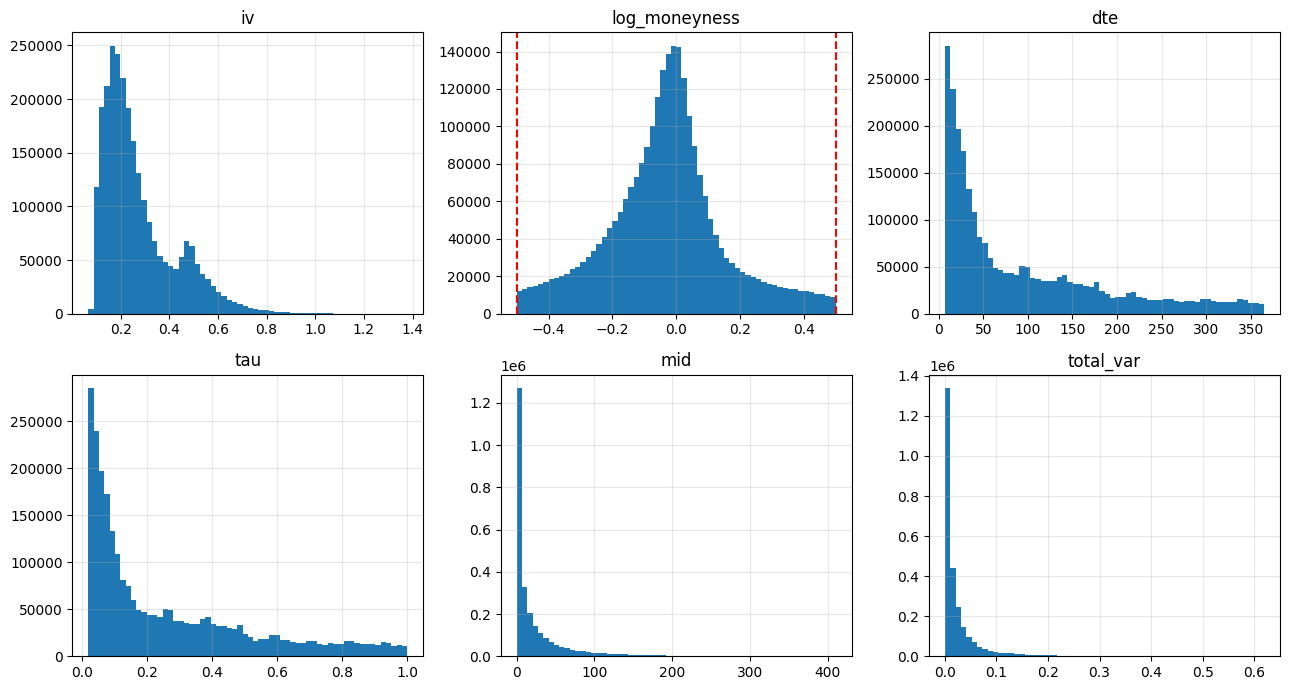

In [22]:
import matplotlib.pyplot as plt

feats = ["iv", "log_moneyness", "dte", "tau", "mid", "total_var"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, f in zip(axes.ravel(), feats):
    ax.hist(df[f].dropna(), bins=60)
    ax.set_title(f); ax.grid(alpha=0.3)
# mark the moneyness clip lines so you can see the filter bit
axes.ravel()[1].axvline(-0.5, color="r", ls="--"); axes.ravel()[1].axvline(0.5, color="r", ls="--")
plt.tight_layout(); plt.show()

In [23]:
df.groupby("ticker").agg(
    rows        = ("iv", "size"),
    dates       = ("quote_date", "nunique"),
    spot_min    = ("underlying_last", "min"),
    spot_max    = ("underlying_last", "max"),
    iv_min      = ("iv", "min"),
    iv_median   = ("iv", "median"),
    iv_max      = ("iv", "max"),
    k_min       = ("log_moneyness", "min"),
    k_max       = ("log_moneyness", "max"),
).round(3)

,rows,dates,spot_min,spot_max,iv_min,iv_median,iv_max,k_min,k_max
ticker,,,,,,,,,
AAPL,111837,250,125.01,198.14,0.127,0.275,1.065,-0.5,0.5
NVDA,225394,250,142.66,504.09,0.238,0.478,1.256,-0.5,0.5
QQQ,534184,250,261.65,411.50,0.095,0.226,0.959,-0.5,0.5
SLV,77927,250,18.39,23.93,0.171,0.312,0.789,-0.5,0.5
SPX,1462299,249,3808.19,4783.83,0.067,0.183,1.033,-0.5,0.5
TSLA,191160,250,108.07,293.37,0.342,0.554,1.379,-0.5,0.5


In [24]:
print(df["type"].value_counts())
print("\nby ticker:")
print(df.groupby(["ticker","type"]).size().unstack(fill_value=0))

type
put     1533167
call    1069634
Name: count, dtype: int64

by ticker:
type      call     put
ticker                
AAPL     57989   53848
NVDA    124709  100685
QQQ     232142  302042
SLV      47785   30142
SPX     494661  967638
TSLA    112348   78812
